<a href="https://colab.research.google.com/github/AcxelCalle/computational-physics/blob/main/InclinedPlaneWithLagrangeMultipliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inclined Plane With Lagrange Multipliers

**Libro**: Marion, Thornton -Classical Dynamics of Particles and Systems

**Problema**: 7.9

![example 7.9.PNG](https://github.com/AcxelCalle/computational-physics/blob/main/example7.9.PNG?raw=true)

<img src="https://github.com/AcxelCalle/computational-physics/blob/main/example6.5.PNG?raw=true" width="400" alt="Texto alternativo">

In [11]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos los símbolos (puedes omitir 'x' e 'y' estáticos si solo usarás las funciones)
t, g, I, M, alpha, R, l = smp.symbols(r't g I M \alpha R l')

# t: tiempo
# g: gravedad
# I: Momento de inercia del disco
# M: Masa del disco
# alpha:  Ángulo de inclinación del plano
# R: Radio del disco
# l: longitud desplazada en el plano

# Defimnimos el multiplicador de Lagrange
lamb = smp.symbols(r'\lambda')

# lamb: lambda

# 2. Definimos las funciones dependientes del tiempo
yp = smp.Function(r'y')(t) #yp : y', usamos un y' porque se fija el origen de coordenadas
                           #     en la parte superior del plano con una inclinación igual a alpha
theta = smp.Function(r'\theta')(t) # theta: Variable independiente en función del tiempo
#x = smp.Function(r'x')(t)

# 3. Construcción del lagrangiano
T = 1/2 * M * smp.diff(yp, t)**2 + 1/4 * M*R**2*smp.diff(theta, t)**2
U = M*g*(l-yp)*smp.sin(alpha)
L = T - U

# 4. Restricción
eq = yp - R*theta # El desplazamiento en y' es igual a R*theta

# 5. Ecuaciones de Euler-Lagrange
EL1 = smp.diff(L, yp) - smp.diff(smp.diff(L, smp.diff(yp, t)), t) + lamb * smp.diff(eq, yp)
EL2 = smp.diff(L, theta) - smp.diff(smp.diff(L, smp.diff(theta, t)), t) + lamb * smp.diff(eq, theta)

# 6. Derivamos la restricción dos veces
eq_ddot = smp.diff(eq, t, 2)

# 7. Variables a despejar
yp_ddot = smp.diff(yp, t, 2)
theta_ddot = smp.diff(theta, t, 2)

# 8. Resolvemos el sistema
sols = smp.solve([EL1, EL2, eq_ddot], (yp_ddot, theta_ddot, lamb))

sols

{\lambda: -0.333333333333333*M*g*sin(\alpha),
 Derivative(\theta(t), (t, 2)): 0.666666666666667*g*sin(\alpha)/R,
 Derivative(y(t), (t, 2)): 0.666666666666667*g*sin(\alpha)}

In [12]:
display(sols[lamb], sols[yp_ddot], sols[theta_ddot])

-0.333333333333333*M*g*sin(\alpha)

0.666666666666667*g*sin(\alpha)

0.666666666666667*g*sin(\alpha)/R

In [13]:
# Usamos odeint para resolver el sistema de ecuaciones diferenciales
from scipy.integrate import odeint

# Definimos las primeras derivadas simbólicas
yp_d = smp.diff(yp, t)
theta_d = smp.diff(theta, t)

# Variables de nuestro sistema
args_simbolicos = (t, g, M, R, alpha)

# 1. Lambdify para las aceleraciones (segundas derivadas obtenidas de 'sols')
# con lambdify convertimos las expresiones simbólicas a numéricas
dvdt_f = smp.lambdify(args_simbolicos, sols[yp_ddot])
domegadt_f = smp.lambdify(args_simbolicos, sols[theta_ddot])

# 2. Lambdify para las velocidades (identidades)
dypdt_f = smp.lambdify(yp_d, yp_d)
dthetadt_f = smp.lambdify(theta_d, theta_d)

In [14]:
def dSdt(S, t, g, M, R, alpha):
    # Desempaquetamos el vector de estado actual
    yp_val, v_val, theta_val, omega_val = S

    # Retornamos las derivadas: [dy_p/dt, dv/dt, dtheta/dt, domega/dt]
    return [
        v_val,                                # dy_p/dt = v
        dvdt_f(t, g, M, R, alpha),            # dv/dt = aceleración lineal
        omega_val,                            # dtheta/dt = omega
        domegadt_f(t, g, M, R, alpha)         # domega/dt = aceleración angular
    ]

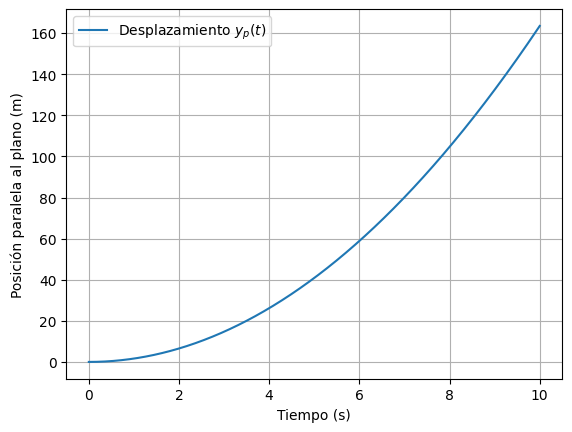

In [15]:
# Parámetros numéricos
g_num = 9.81
M_num = 1.0  # kg
R_num = 10  # metros
alpha_num = np.pi / 6  # 30 grados (en radianes)

# Vector de tiempo (ej. 10 segundos, 1000 puntos)
t_num = np.linspace(0, 10, 1000)

# Condiciones iniciales: [yp_0, v_0, theta_0, omega_0]
# El disco parte del reposo en la posición 0
S0 = [0.0, 0.0, 0.0, 0.0]

# Resolvemos el sistema
ans = odeint(dSdt, y0=S0, t=t_num, args=(g_num, M_num, R_num, alpha_num))

# Extraemos las posiciones de la matriz de resultados (transpuesta para facilitar lectura)
yp_num = ans.T[0]
theta_num = ans.T[2]

# Graficamos el desplazamiento yp en función del tiempo
plt.plot(t_num, yp_num, label='Desplazamiento $y_p(t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición paralela al plano (m)')
plt.legend()
plt.grid(True)
plt.show()

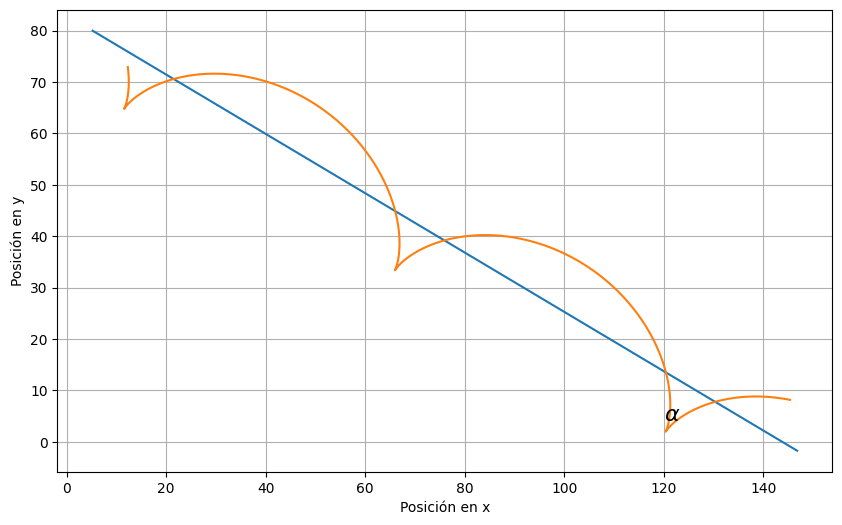

In [16]:
###########################################
# Transformación a coordenadas cartesianas
###########################################

# Longitud del plano
l = 160

# Posición del centro del disco
y = (l - yp_num) * np.sin(alpha_num)
x = yp_num * np.cos(alpha_num)

# Posición del centro del disco según diagrama
x = x + R_num * alpha_num

# Posición de un punto del borde del disco
xD = x + R_num*np.cos(-theta_num-np.pi/4)
yD = y + R_num*np.sin(-theta_num-np.pi/4)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.plot(xD, yD)
plt.xlabel('Posición en x')
plt.ylabel('Posición en y')
plt.text(120, 4, r'$\alpha$', fontsize=16)
plt.grid(True)
plt.show()

In [17]:
###############################################
#         ANIMACIÓN DEL SISTEMA
###############################################

import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML

# Longitud del plano
l = 160

# 1. Transformación geométrica correcta
# El centro (xc, yc) se levanta del plano una distancia R perpendicularmente
xc = yp_num * np.cos(alpha_num) + R_num * np.sin(alpha_num)
yc = (l - yp_num) * np.sin(alpha_num) + R_num * np.cos(alpha_num)

# Un punto en el borde (xD, yD) que empieza tocando el plano
# Restamos theta_num porque, al bajar, el disco gira en sentido horario (negativo)
xD = xc - R_num * np.sin(alpha_num + theta_num)
yD = yc - R_num * np.cos(alpha_num + theta_num)

# 2. Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 6))

# Triángulo AOB (Plano inclinado, ángulo recto en O)
ax.plot([0, 0, l*np.cos(alpha_num), 0],
        [0, l*np.sin(alpha_num), 0, 0], 'k-', lw=3)

# Textos
ax.text(-5, -5, 'O', fontsize=14, fontweight='bold')
ax.text(-5, l*np.sin(alpha_num), 'A', fontsize=14, fontweight='bold')
ax.text(l*np.cos(alpha_num) + 2, -5, 'B', fontsize=14, fontweight='bold')
ax.text(l*np.cos(alpha_num) - 20, 4, r'$\alpha$', fontsize=16)

# Ejes
ax.set_aspect('equal')
ax.set_xlim(-10, l*np.cos(alpha_num) + 20)
ax.set_ylim(-10, l*np.sin(alpha_num) + 20)
ax.set_xlabel('Posición en x (m)')
ax.set_ylabel('Posición en y (m)')
ax.grid(True, linestyle='--', alpha=0.6)

# 3. Elementos dinámicos
disco = Circle((xc[0], yc[0]), R_num, facecolor='lightblue', edgecolor='blue', lw=2)
ax.add_patch(disco)

punto_borde, = ax.plot([], [], 'ro', markersize=6)
rastro, = ax.plot([], [], 'r--', alpha=0.5)

plt.close() # Evita imprimir el frame estático vacío en Colab

# 4. Funciones de animación
# Saltamos frames (stride) para que los 1000 puntos no hagan la animación demasiado pesada en Colab
paso = 10
frames_totales = len(yp_num) // paso

def init():
    disco.center = (xc[0], yc[0])
    punto_borde.set_data([xD[0]], [yD[0]])
    rastro.set_data([], [])
    return disco, punto_borde, rastro

def update(frame):
    i = frame * paso # Índice real en tu array de 1000 puntos

    disco.center = (xc[i], yc[i])
    punto_borde.set_data([xD[i]], [yD[i]])
    rastro.set_data(xD[:i], yD[:i]) # Historial del rastro hasta el frame actual

    return disco, punto_borde, rastro

# 5. Generar y mostrar
ani = animation.FuncAnimation(fig, update, frames=frames_totales,
                              init_func=init, blit=True, interval=30)

HTML(ani.to_jshtml())